## Clusterizaciòn de codificaciones

## Importación de librerias necesarias

In [2]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [3]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")

JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [4]:
from pyspark.sql import functions as F, types as T, DataFrame, Window
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.cluster import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.clustering import KMeans, KMeansModel
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import array_to_vector
from src.gold.training.pca import PCAEncoder

In [5]:
from src.utils.spark import SparkUtils
spark_utils = SparkUtils('clusterize_encodings')
spark = spark_utils.spark

2025-10-19 22:20:52.213628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-19 22:20:52.225469: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-19 22:20:52.228816: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-19 22:20:52.238170: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-19 22:20:54.012534: W tensorflow/compiler/tf2

:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f91716a3-2d56-40ca-90fa-688049c0120d;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 105ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

In [6]:
REGENERATE_INTERMEDIATE_TABLES = False

In [7]:
GOLD_SCHEMA = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
GOLD_SCHEMA_ENCODING = 'gold.encoding'
SCHEMA = 'silver.preprocess'

## Cargar información de codificaciones

In [8]:
main_category_encoded = spark.read.format('delta').load(spark_utils.path(
    'main_category_encoded', catalog = GOLD_SCHEMA
))

meta_items_embeddings_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_equi', catalog = GOLD_SCHEMA_ENCODING
))

meta_items_embeddings_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_tfidf', catalog = GOLD_SCHEMA_ENCODING
))

In [9]:
df_vectorized = meta_items_embeddings_equi.withColumn("features", array_to_vector("sum_embedding"))
df_vectorized_tfidf = meta_items_embeddings_tfidf.withColumn("features", array_to_vector("sum_embedding"))

## Clusterización K-Means

### Caso Fair Embedding (Promedio sin distinción)

In [10]:
kmeans = KMeans(
    featuresCol="features", predictionCol="cluster", k=200,
    distanceMeasure="cosine"
)

In [11]:
if REGENERATE_INTERMEDIATE_TABLES:
    model = kmeans.fit(df_vectorized)
    model.write().overwrite().save(spark_utils.path('kmeans_model', catalog = GOLD_SCHEMA_CLUSTER))

model = KMeansModel.load(spark_utils.path('kmeans_model', catalog = GOLD_SCHEMA_CLUSTER))

In [12]:
if REGENERATE_INTERMEDIATE_TABLES:
    meta_items_clustered_equi = model.transform(df_vectorized)
    (
        meta_items_clustered_equi.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('meta_items_embeddings_equi_clustered', catalog = GOLD_SCHEMA_CLUSTER))
    )

meta_items_clustered_equi = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_equi_clustered', catalog = GOLD_SCHEMA_CLUSTER
))

### Caso TFIDF

In [13]:
kmeans_tfidf = KMeans(
    featuresCol="features", predictionCol="cluster", k=200,
    distanceMeasure="cosine"
)

In [14]:
if REGENERATE_INTERMEDIATE_TABLES:
    model_tfidf = kmeans_tfidf.fit(df_vectorized_tfidf)
    model_tfidf.write().overwrite().save(spark_utils.path('kmeans_model_tfidf', catalog = GOLD_SCHEMA_CLUSTER))

model_tfidf = KMeansModel.load(spark_utils.path('kmeans_model_tfidf', catalog = GOLD_SCHEMA_CLUSTER))

In [15]:
if REGENERATE_INTERMEDIATE_TABLES:
    meta_items_clustered_tfidf = model_tfidf.transform(df_vectorized_tfidf)
    (
        meta_items_clustered_tfidf.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('meta_items_embeddings_tfidf_clustered', catalog = GOLD_SCHEMA_CLUSTER))
    )

meta_items_clustered_tfidf = spark.read.format('delta').load(spark_utils.path(
    'meta_items_embeddings_tfidf_clustered', catalog = GOLD_SCHEMA_CLUSTER
))

In [16]:
meta_items_clustered_tfidf.count()

456530

## Visualizar distribución de codificaciones

### Caso Fair Embedding (Promedio sin distinción)

In [17]:
avg_encoded_split_with_embeddings_counts_equi = (
    meta_items_clustered_equi
        .groupBy('cluster')
        .count()
        .orderBy('cluster')
).toPandas()

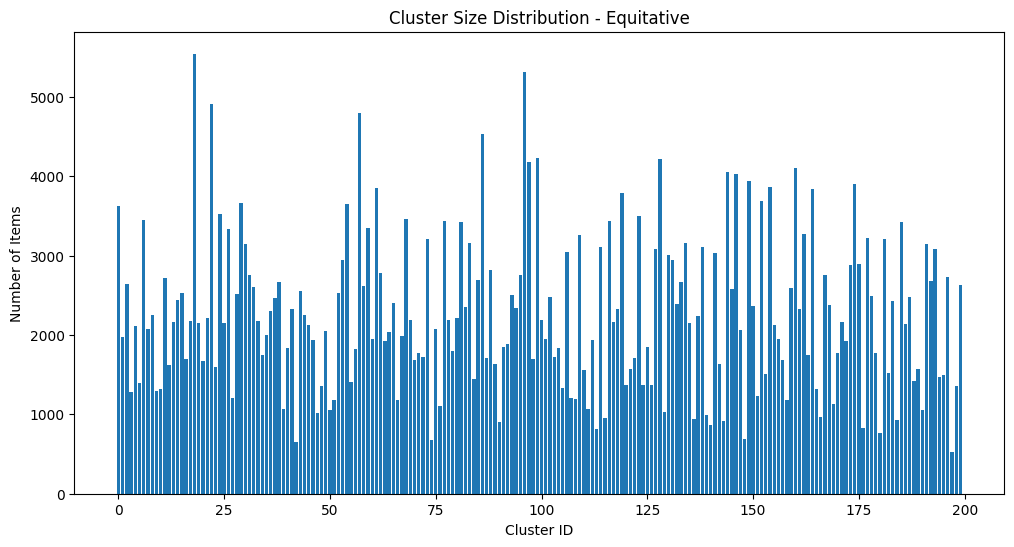

In [18]:
plt.figure(figsize=(12, 6))
plt.bar(
    avg_encoded_split_with_embeddings_counts_equi['cluster'],
    avg_encoded_split_with_embeddings_counts_equi['count']
)
plt.title('Cluster Size Distribution - Equitative')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.show()

In [19]:
evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="cosine"
)

silhouette_score_equi = evaluator.evaluate(meta_items_clustered_equi)

In [20]:
silhouette_score_equi

0.03151327113801003

### Caso TFIDF

In [21]:
avg_encoded_split_with_embeddings_counts_tfidf = (
    meta_items_clustered_tfidf
        .groupBy('cluster')
        .count()
        .orderBy('cluster')
).toPandas()

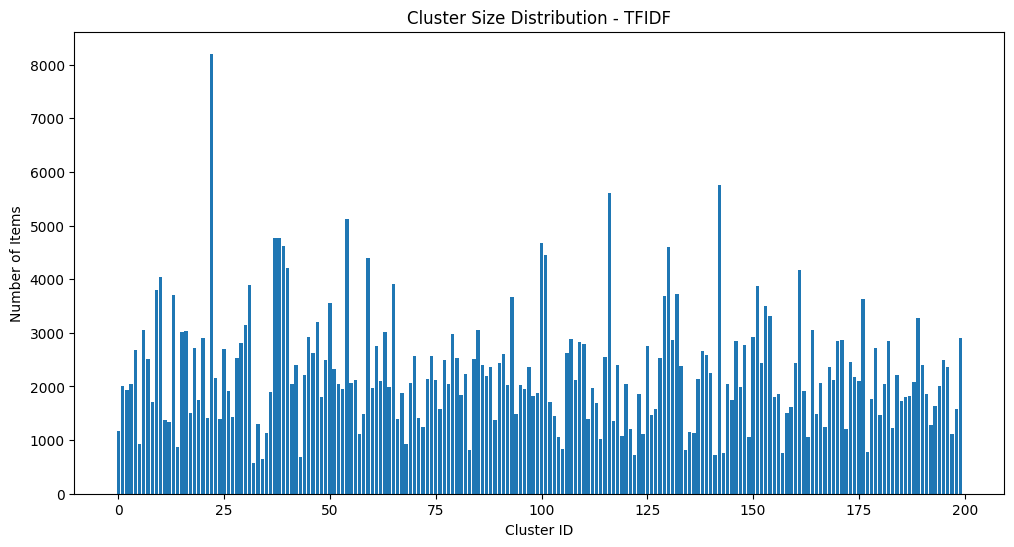

In [22]:
plt.figure(figsize=(12, 6))
plt.bar(
    avg_encoded_split_with_embeddings_counts_tfidf['cluster'],
    avg_encoded_split_with_embeddings_counts_tfidf['count']
)
plt.title('Cluster Size Distribution - TFIDF')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.show()

In [23]:
evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="cosine"
)

silhouette_score_tfidf = evaluator.evaluate(meta_items_clustered_tfidf)

In [24]:
silhouette_score_tfidf

0.05384043029983401

## Reducción de componentes (PCA)

In [25]:
df_vectorized_pca = spark.read.format('delta').load(spark_utils.path(
    'df_vectorized_pca', catalog = GOLD_SCHEMA_CLUSTER
))

## Weighted sample selection for further analysis

In [26]:
df_vectorized_pca.show(1)

+-----------+--------------------+--------------------+--------------------+
|parent_asin|       sum_embedding|            features|        pca_features|
+-----------+--------------------+--------------------+--------------------+
| 1934931519|[0.01391693763434...|[0.01391693763434...|[0.49281224836740...|
+-----------+--------------------+--------------------+--------------------+
only showing top 1 row



In [27]:
main_category_columns = [col for col in main_category_encoded.columns if col.startswith('main_category_')]

df_with_categories = df_vectorized_pca.join(
    main_category_encoded.select('parent_asin', *main_category_columns),
    on='parent_asin',
    how='inner'
)

samples_per_class = []
for category_col in main_category_columns:
    category_samples = (
        df_with_categories
        .filter(F.col(category_col) == 1)
        .sample(1.0, seed=42)
        .limit(1000)
    )
    samples_per_class.append(category_samples)

df_weighted_sample = samples_per_class[0]
for sample_df in samples_per_class[1:]:
    df_weighted_sample = df_weighted_sample.union(sample_df)


In [28]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        df_weighted_sample.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('df_weighted_sample', catalog=GOLD_SCHEMA_CLUSTER))
    )

df_weighted_sample = spark.read.format('delta').load(spark_utils.path(
    'df_weighted_sample', catalog=GOLD_SCHEMA_CLUSTER
))

## Hierarchical Clustering with Cosine Similarity


In [29]:
REGENERATE_HIERARCHICAL = False
N_CLUSTERS_HIERARCHICAL = 150

In [30]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering

pdf = df_weighted_sample.select("parent_asin", "pca_features").toPandas()
embeddings = np.vstack(pdf["pca_features"].values)

model = AgglomerativeClustering(
    linkage='average',
    n_clusters=None,
    distance_threshold=0.5,
    metric='cosine'
)

labels = model.fit_predict(embeddings)
pdf["cluster_hierarchical"] = labels
sample_equitative_hierarchical = spark.createDataFrame(pdf)

In [31]:
if REGENERATE_INTERMEDIATE_TABLES:
    (
        sample_equitative_hierarchical.write
            .format('delta')
            .mode('overwrite')
            .save(spark_utils.path('sample_equitative_hierarchical', catalog=GOLD_SCHEMA_CLUSTER))
    )

sample_equitative_hierarchical = spark.read.format('delta').load(spark_utils.path(
    'sample_equitative_hierarchical', catalog=GOLD_SCHEMA_CLUSTER
))

In [33]:
hier_avg_encoded_split_with_embeddings_counts_equi = (
    sample_equitative_hierarchical
        .groupBy('cluster_hierarchical')
        .count()
        .orderBy('cluster_hierarchical')
).toPandas()

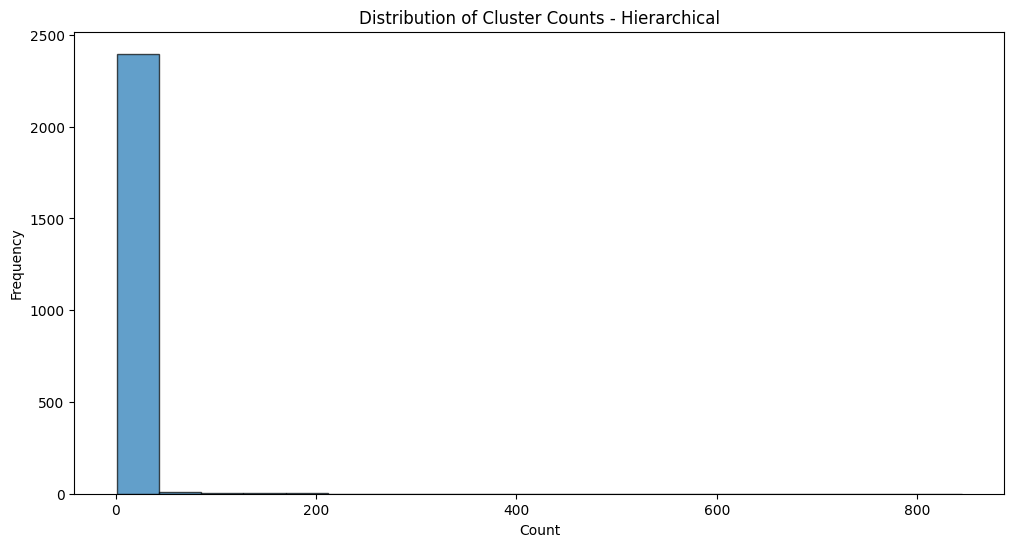

In [34]:
plt.figure(figsize=(12, 6))
plt.hist(
    hier_avg_encoded_split_with_embeddings_counts_equi['count'],
    bins=20,
    edgecolor='black',
    alpha=0.7
)
plt.title('Distribution of Cluster Counts - Hierarchical')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

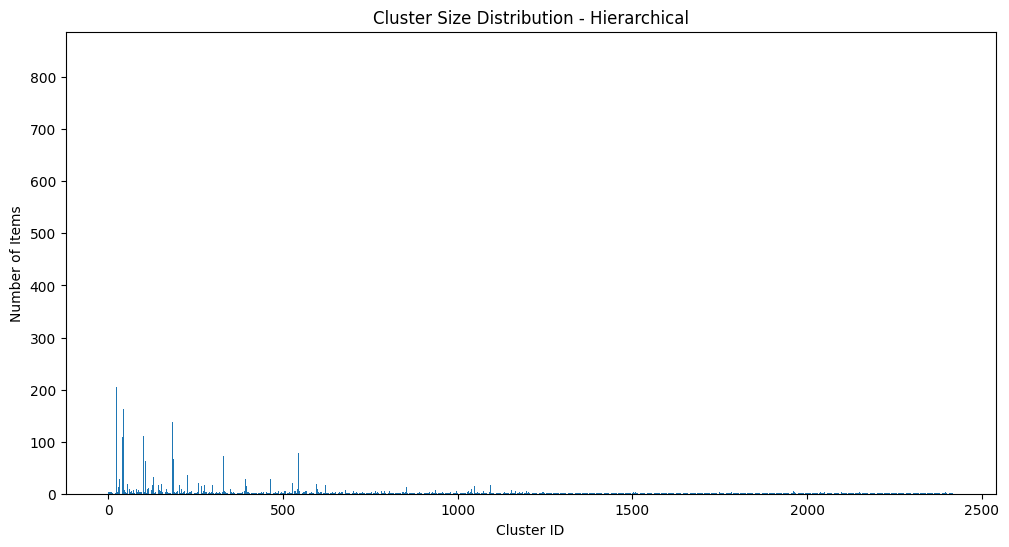

In [35]:
plt.figure(figsize=(12, 6))
plt.bar(
    hier_avg_encoded_split_with_embeddings_counts_equi['cluster_hierarchical'],
    hier_avg_encoded_split_with_embeddings_counts_equi['count']
)
plt.title('Cluster Size Distribution - Hierarchical')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.show()

In [36]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

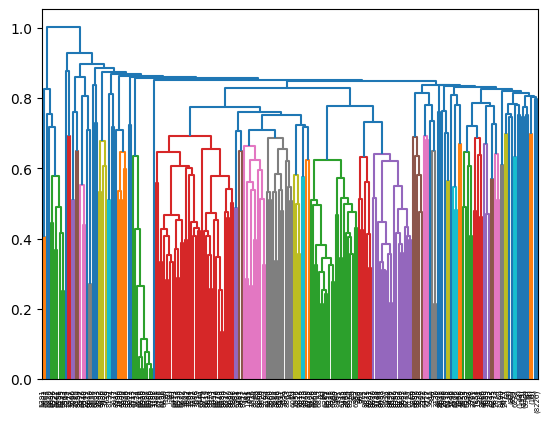

In [37]:
plot_dendrogram(model, truncate_mode="level", p=20)

## ECSAGO Algorithm Implementation


In [38]:
from src.utils.models.ecsago import ECSAGO

In [39]:
df_weighted_sample.show(1)

+-----------+--------------------+--------------------+--------------------+-----------------------+-----------------------------+--------------------------------+-------------------------+-----------------------------------+-------------------------------------+-----------------------------+-----------------------------+--------------------------+
|parent_asin|       sum_embedding|            features|        pca_features|main_category_computers|main_category_all_electronics|main_category_home_audio_theater|main_category_amazon_home|main_category_industrial_scientific|main_category_cell_phones_accessories|main_category_car_electronics|main_category_office_products|main_category_camera_photo|
+-----------+--------------------+--------------------+--------------------+-----------------------+-----------------------------+--------------------------------+-------------------------+-----------------------------------+-------------------------------------+-----------------------------+-----

In [40]:
sample_data = df_weighted_sample.select("parent_asin", "pca_features").toPandas()
embeddings_sample = np.vstack(sample_data["pca_features"].values)

print(f"Sample data shape: {embeddings_sample.shape}")
print(f"Number of samples: {len(sample_data)}")


Sample data shape: (9000, 150)
Number of samples: 9000


In [41]:
ecsago_model = ECSAGO(
    n_clusters=50,
    max_iter=50,
    num_agents=20,
    chaos_map='logistic',
    convergence_threshold=1e-6,
    random_state=42
)

ecsago_labels = ecsago_model.fit_predict(embeddings_sample)

print(f"ECSAGO clustering completed in {ecsago_model.n_iter_} iterations")
print(f"Inertia: {ecsago_model.inertia_:.4f}")
print(f"Number of clusters found: {len(np.unique(ecsago_labels))}")


ECSAGO clustering completed in 2 iterations
Inertia: 4389.4648
Number of clusters found: 45


In [42]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

silhouette_ecsago = silhouette_score(embeddings_sample, ecsago_labels)
calinski_ecsago = calinski_harabasz_score(embeddings_sample, ecsago_labels)
davies_bouldin_ecsago = davies_bouldin_score(embeddings_sample, ecsago_labels)

print("ECSAGO Clustering Metrics:")
print(f"Silhouette Score: {silhouette_ecsago:.4f}")
print(f"Calinski-Harabasz Index: {calinski_ecsago:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_ecsago:.4f}")


ECSAGO Clustering Metrics:
Silhouette Score: -0.3338
Calinski-Harabasz Index: 17.8935
Davies-Bouldin Index: 3.7061


In [43]:
ecsago_labels_counts = pd.Series(ecsago_labels).value_counts().sort_index()

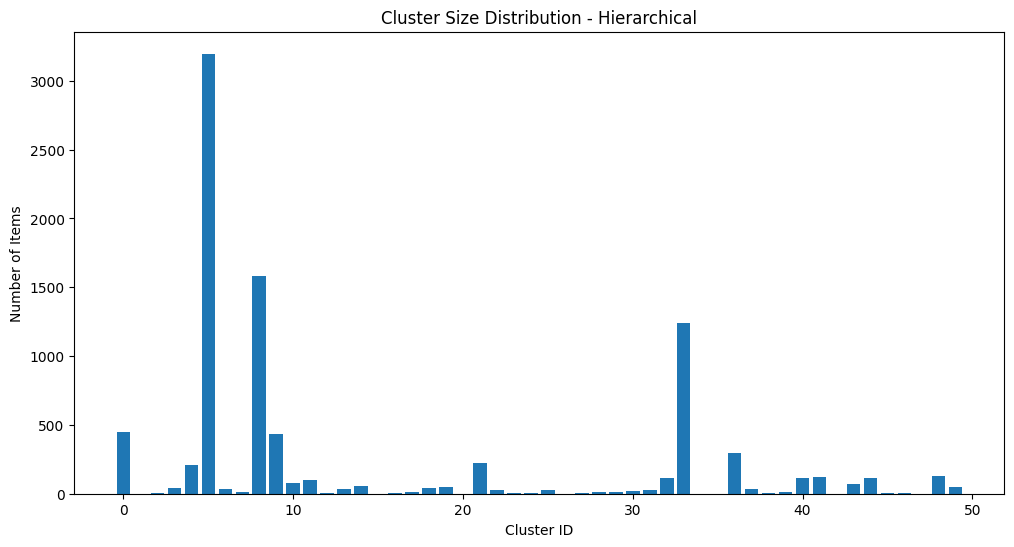

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(
    ecsago_labels_counts.index,
    ecsago_labels_counts.values
)
plt.title('Cluster Size Distribution - ECSAGO')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Items')
plt.show()